### En este jupyter se desarollaran los modelos:
Se desarrollaran los módelos de aprendizaje supervidado

In [ ]:
# numpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#sklearn
from sklearn.preprocessing import ( 
                                   LabelEncoder,
                                   RobustScaler
                                   )
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
                            confusion_matrix, 
                            classification_report,
                            accuracy_score,
                            ConfusionMatrixDisplay
                            )

from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import umap.umap_ as umap


In [ ]:
path = "data/Data_numerical.csv"
df_munis = pd.read_csv(path)

In [15]:
df_munis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64487 entries, 0 to 64486
Data columns (total 49 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   CantidadItem                                                        64487 non-null  int64  
 1   Monto_Total_Orden                                                   64487 non-null  float64
 2   is_expensive                                                        64487 non-null  bool   
 3   EstadoOC_En Proceso                                                 64487 non-null  bool   
 4   EstadoOC_Enviada a Proveedor                                        64487 non-null  bool   
 5   EstadoOC_Recepcion Conforme                                         64487 non-null  bool   
 6   EstadoOC_Solicitud de Cancelacion                                   64487 non-null  bool   
 7   TipoDespacho_

### Aplicación de RobustScaler

In [ ]:
numerical_data = ['CantidadItem','Monto_Total_Orden']

for col in numerical_data:
    df_munis[f'{col}_log'] = np.log1p(df_munis[col].astype(float))

scaler = RobustScaler()

cols_log_names = [f'{c}_log' for c in numerical_data]
df_munis[cols_log_names] = scaler.fit_transform(df_munis[cols_log_names])

df_munis = df_munis.drop(columns=['CantidadItem', 'Monto_Total_Orden'])
                                                                 

In [23]:
df_munis = df_munis.dropna()

### Separar X e Y

In [24]:
# Separar X (características) e y (etiqueta)
X = df_munis.drop(columns=["is_expensive"]).copy()
y = df_munis["is_expensive"].copy()

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61784 entries, 0 to 64486
Data columns (total 48 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   EstadoOC_En Proceso                                                 61784 non-null  bool   
 1   EstadoOC_Enviada a Proveedor                                        61784 non-null  bool   
 2   EstadoOC_Recepcion Conforme                                         61784 non-null  bool   
 3   EstadoOC_Solicitud de Cancelacion                                   61784 non-null  bool   
 4   TipoDespacho_Despachar a Dirección de envío                         61784 non-null  bool   
 5   TipoDespacho_Despachar según programa adjuntado                     61784 non-null  bool   
 6   TipoDespacho_Despacho por courier o encomienda terrestre            61784 non-null  bool   
 7   TipoDespacho_Otra 

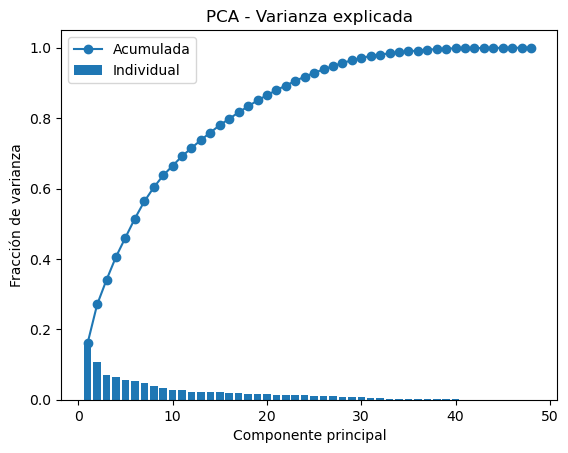

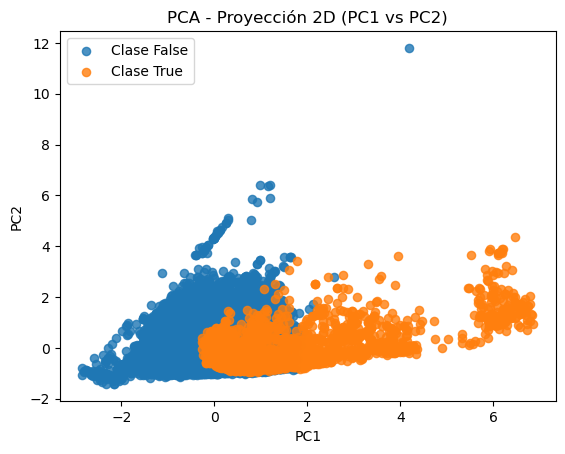

In [26]:
pca = PCA()
pca.fit(X)

exp_var = pca.explained_variance_ratio_
cum_exp = np.cumsum(exp_var)
k = len(exp_var)

# Varianza explicada
fig, ax = plt.subplots()
ax.bar(range(1, k+1), exp_var, label="Individual")
ax.plot(range(1, k+1), cum_exp, marker="o", label="Acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Fracción de varianza")
ax.set_title("PCA - Varianza explicada")
ax.legend()
plt.show()

# Proyección 2D
Z = pca.transform(X)
pc1, pc2 = Z[:,0], Z[:,1]

fig, ax = plt.subplots()
for c in np.unique(y):
    sel = y.values == c
    ax.scatter(pc1[sel], pc2[sel], s=35, alpha=0.8, label=f"Clase {c}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - Proyección 2D (PC1 vs PC2)")
ax.legend(loc='upper left')
plt.show()

In [28]:
pca = PCA(n_components=0.90)  #  buscamos  un 90% de varianza explicada
X_pca = pca.fit_transform(X)
print(f"Número de componentes necesarios: {pca.n_components_}")

Número de componentes necesarios: 23


# Vizualización

### TSNE

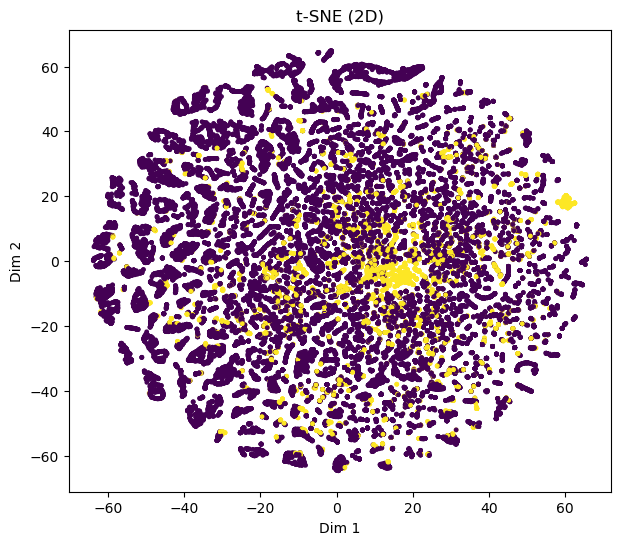

In [ ]:
# con pca
tsne2 = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', max_iter=500, random_state=42)
X_tsne2 = tsne2.fit_transform(X_pca)
label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y), index=y.index, name='is_expensive')
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_tsne2[:,0], X_tsne2[:,1], c=y, s=6)
plt.title("t-SNE (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

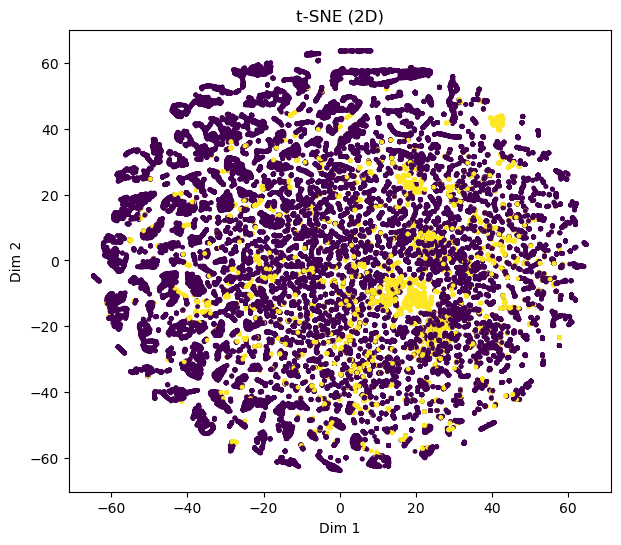

In [33]:
# sin pca
tsne2 = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', max_iter=500, random_state=42)
X_tsne2 = tsne2.fit_transform(X)
label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y), index=y.index, name='is_expensive')
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_tsne2[:,0], X_tsne2[:,1], c=y, s=6)
plt.title("t-SNE (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()


## TEST Y TRAIN

In [34]:
X = X_pca
y = y

In [35]:
# Split , en train 80% y test 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## REGRESIÓN LÓGISTICA

In [36]:
### Funciones 
def LogisticRegression_results(X_train, X_test, y_train, y_test, solver):
    logreg = LogisticRegression(solver=solver, max_iter=1000, random_state=42, class_weight='balanced')
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)

    print(classification_report(y_test, y_pred)) 
    print(confusion_matrix(y_test, y_pred))   

In [37]:
LogisticRegression_results(X_train, X_test, y_train, y_test, solver='lbfgs')

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     11143
           1       0.49      0.91      0.64      1214

    accuracy                           0.90     12357
   macro avg       0.74      0.91      0.79     12357
weighted avg       0.94      0.90      0.91     12357

[[10012  1131]
 [  107  1107]]


In [38]:
LogisticRegression_results(X_train, X_test, y_train, y_test, solver='liblinear')

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     11143
           1       0.49      0.91      0.64      1214

    accuracy                           0.90     12357
   macro avg       0.74      0.91      0.79     12357
weighted avg       0.94      0.90      0.91     12357

[[10012  1131]
 [  107  1107]]


### 3.3 k-Nearest Neighbors

In [54]:
X_sin_drop = df_munis.drop(columns=["is_expensive"]).copy()
nombres_columnas = X_sin_drop.columns 

In [55]:
X = X_sin_drop
y = y

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def obtener_mejor_k(X_train, y_train):
    k_values = range(2, 11)
    scores = []
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring="f1_macro").mean()
        scores.append(cv_score)

    best_k = k_values[np.argmax(scores)]

    plt.figure(figsize=(7,5))
    plt.plot(k_values, scores, marker="o")
    plt.xlabel("Número de vecinos K")
    plt.ylabel("F1 macro (CV 5-fold)")
    plt.title("Selección del mejor K")
    plt.show()
    
    return best_k

def resultados_KNN_ajustado(X_train, X_test, y_train, y_test, best_k, umbral=0.3):
    
    knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
    knn.fit(X_train, y_train)
    
    y_proba = knn.predict_proba(X_test)[:, 1]
    
    y_pred_ajustado = (y_proba >= umbral).astype(int)
    
    print(f"--- Resultados con Umbral {umbral} ---")
    print(classification_report(y_test, y_pred_ajustado, digits=3))
    print(confusion_matrix(y_test, y_pred_ajustado))
    
    return  knn


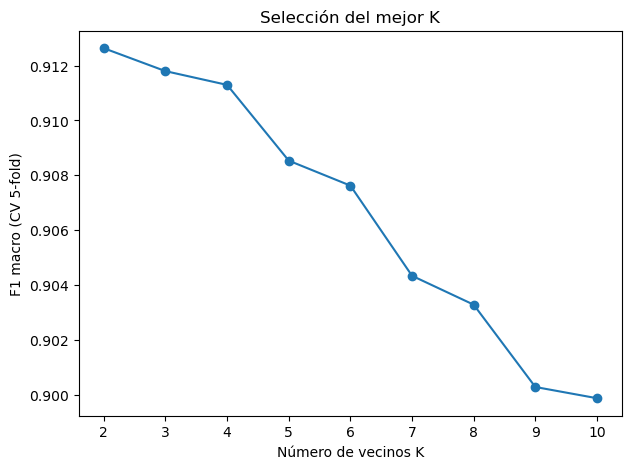

In [57]:
mejor_k = obtener_mejor_k(X_train, y_train)

In [60]:
knn = resultados_KNN_ajustado(X_train, X_test, y_train, y_test, mejor_k+2)

--- Resultados con Umbral 0.3 ---
              precision    recall  f1-score   support

           0      0.984     0.982     0.983     11143
           1      0.838     0.849     0.843      1214

    accuracy                          0.969     12357
   macro avg      0.911     0.916     0.913     12357
weighted avg      0.969     0.969     0.969     12357

[[10943   200]
 [  183  1031]]


### Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [62]:
def mejor_estimador_rf(X_train, X_test, y_train, y_test):
    accuracies = []
    n_estimators_list = [100, 200, 300, 400, 500]

    for n_est in n_estimators_list:
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=10,
            max_features='sqrt',
            random_state=42,
            class_weight='balanced'
        )
        rf.fit(X_train, y_train)
        yhat_test = rf.predict(X_test)
        accuracies.append(accuracy_score(y_test, yhat_test))

    plt.plot(n_estimators_list, accuracies, marker="o", linestyle="-")
    plt.xlabel("Número de Estimadores")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Número de Estimadores")
    plt.grid(True)
    plt.show()
    

    best_idx = np.argmax(accuracies)
    best_n_estimators = n_estimators_list[best_idx]
    
    return best_n_estimators


def resultados_rf(X_train, X_test, y_train, y_test, mejor_n):
    rf = RandomForestClassifier(
        n_estimators=mejor_n,
        max_depth=7,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)
    yhat_rf_train = rf.predict(X_train)
    yhat_rf_test = rf.predict(X_test)

    print('Random Forest - Accuracy train:', accuracy_score(y_train, yhat_rf_train))
    print('Random Forest - Accuracy test :', accuracy_score(y_test, yhat_rf_test))
    print('OOB score:', rf.oob_score_)
    print('\nReporte (test):\n', classification_report(y_test, yhat_rf_test))
    print('Matriz de confusión (test):\n', confusion_matrix(y_test, yhat_rf_test))
    
    return rf

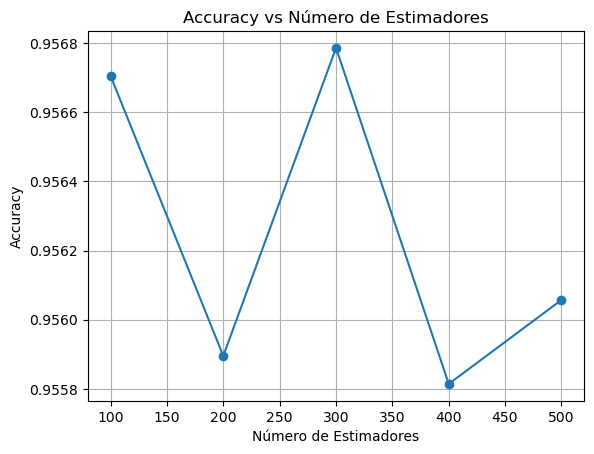

In [63]:
mejor_n = mejor_estimador_rf(X_train, X_test, y_train, y_test)

In [64]:
rf = resultados_rf(X_train, X_test, y_train, y_test, 300)

Random Forest - Accuracy train: 0.9241912315131406
Random Forest - Accuracy test : 0.9231204985028728
OOB score: 0.9220466546624315

Reporte (test):
               precision    recall  f1-score   support

           0       0.99      0.92      0.96     11143
           1       0.56      0.96      0.71      1214

    accuracy                           0.92     12357
   macro avg       0.78      0.94      0.83     12357
weighted avg       0.95      0.92      0.93     12357

Matriz de confusión (test):
 [[10246   897]
 [   53  1161]]
